In [1]:
from qiskit import QuantumCircuit, ClassicalRegister
from qiskit.circuit.library import UnitaryGate, Reset
import matplotlib.pyplot as plt
import math
import numpy as np

from qiskit.quantum_info import Statevector


from qiskit.visualization import array_to_latex
from IPython.display import display


2x2 rotational block matrix, pi/3 angle

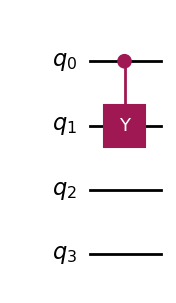

In [2]:
qc = QuantumCircuit(4)
qc.cy(0,1)

qc.draw("mpl")

In [3]:
import qiskit.circuit.library as qulib

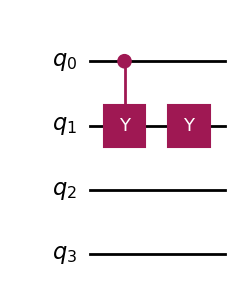

In [4]:
Y_gate = qulib.YGate()
qc.append(Y_gate, [1])
qc.draw("mpl")

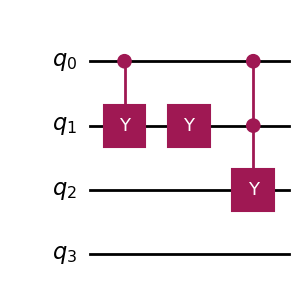

In [5]:
cy_gate = qulib.YGate().control(2)
qc.append(cy_gate, [0, 1, 2])
qc.draw("mpl")

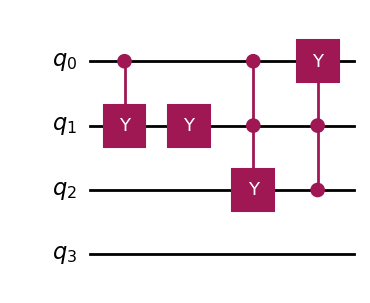

In [6]:
cy_gate = qulib.YGate().control(2)
qc.append(cy_gate, [2, 1, 0])
qc.draw("mpl")

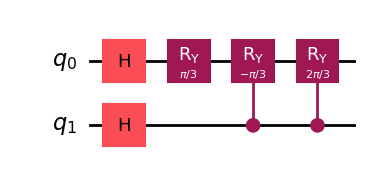

In [7]:
qc = QuantumCircuit(2)
qc.h(0)
qc.h(1)
qc.ry(np.pi/3, 0)
qc.cry(-np.pi/3, 1,0)
qc.cry(2*np.pi/3, 1,0)
qc.draw("mpl")

DataBin(meas=BitArray(<shape=(), num_shots=1024, num_bits=2>))
{'11': 465, '01': 483, '10': 40, '00': 36}


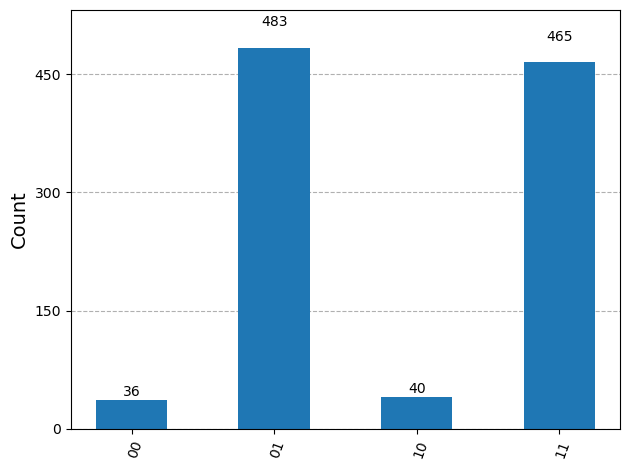

In [8]:
from qiskit.primitives import StatevectorSampler
from qiskit.visualization import plot_histogram, plot_state_city
sampler=StatevectorSampler()

qc_measured = qc.measure_all(inplace=False)
job=sampler.run([qc_measured],shots=1024)
result= job.result()

result = job.result()

print(result[0].data)
counts = result[0].data.meas.get_counts()
print(counts)

plot_histogram(counts)

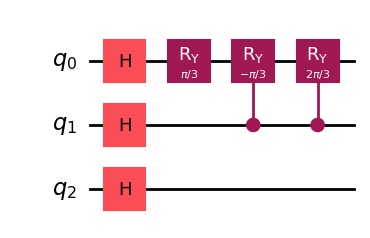

In [9]:
qc = QuantumCircuit(3)
for qubit in range(3):
    qc.h(qubit)
    
qc.ry(np.pi/3, 0)
qc.cry(-np.pi/3, 1,0)
qc.cry(2*np.pi/3, 1,0)


qc.draw("mpl")

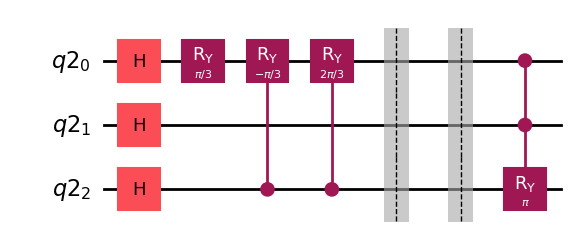

In [18]:
from qiskit import QuantumCircuit,QuantumRegister
from qiskit.circuit.library.standard_gates import RYGate
from qiskit.circuit import Parameter
import matplotlib.pyplot as plt

qr=QuantumRegister(3)
circ=QuantumCircuit(qr)

for qubit in range(3):
    circ.h(qubit)
    
circ.ry(np.pi/3, 0)
circ.cry(-np.pi/3, 2,0)
circ.cry(2*np.pi/3, 2,0)

circ.barrier(0,1,2)

#cry_gate = qulib.RYGate(2*np.pi/3).control(2)
#circ.append(cry_gate, [0, 2, 1])

circ.barrier(0,1,2)

#Last part of matrix
CCRY=RYGate(np.pi).control(2)
circ.append(CCRY,qr)
circ.draw("mpl")

DataBin(meas=BitArray(<shape=(), num_shots=1024, num_bits=3>))
{'001': 233, '101': 231, '111': 260, '011': 234, '010': 22, '110': 18, '100': 17, '000': 9}


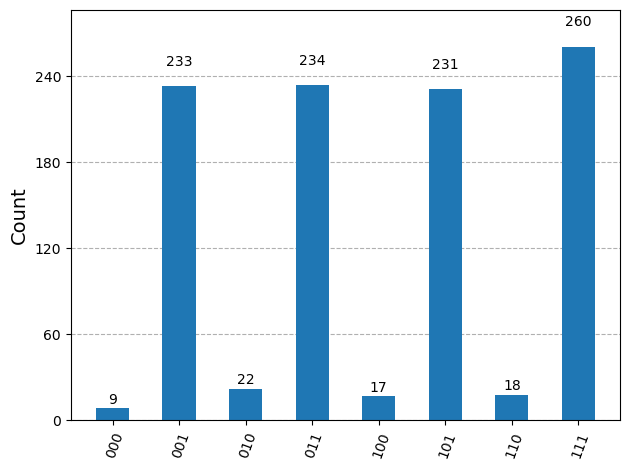

In [19]:
qc_measured = circ.measure_all(inplace=False)
job=sampler.run([qc_measured],shots=1024)
result= job.result()

result = job.result()

print(result[0].data)
counts = result[0].data.meas.get_counts()
print(counts)

plot_histogram(counts)

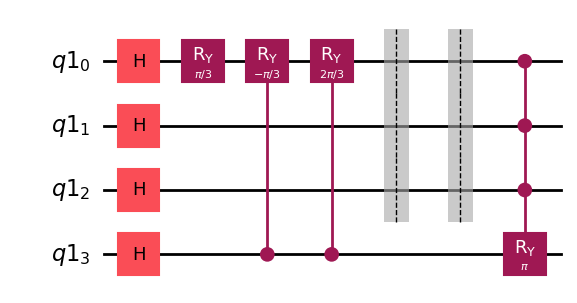

In [12]:
from qiskit import QuantumCircuit,QuantumRegister
from qiskit.circuit.library.standard_gates import RYGate
from qiskit.circuit import Parameter
import matplotlib.pyplot as plt

qr=QuantumRegister(4)
circ=QuantumCircuit(qr)

for qubit in range(4):
    circ.h(qubit)
    
circ.ry(np.pi/3, 0)
circ.cry(-np.pi/3, 3,0)
circ.cry(2*np.pi/3, 3,0)

circ.barrier(0,1,2)

#cry_gate = qulib.RYGate(2*np.pi/3).control(2)
#circ.append(cry_gate, [0, 2, 1])

circ.barrier(0,1,2)

#Last part of matrix
CCRY=RYGate(np.pi).control(3)
circ.append(CCRY,qr)
circ.draw("mpl")

DataBin(meas=BitArray(<shape=(), num_shots=1024, num_bits=4>))
{'1001': 127, '0110': 5, '1101': 121, '0101': 98, '1011': 116, '0001': 126, '0111': 125, '0011': 129, '1111': 107, '0010': 11, '1110': 16, '1010': 8, '0100': 9, '1000': 7, '1100': 11, '0000': 8}


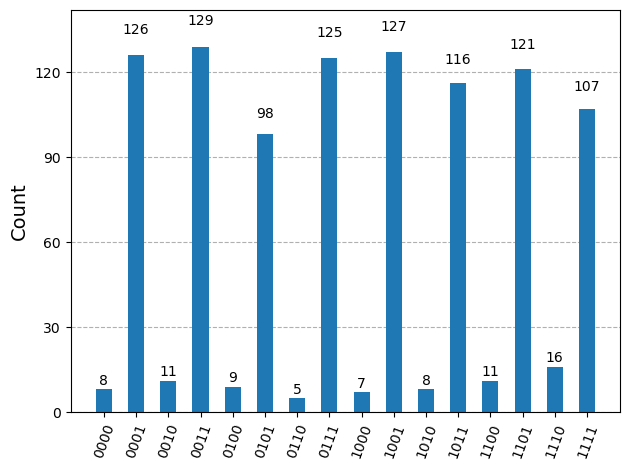

In [13]:
qc_measured = circ.measure_all(inplace=False)
job=sampler.run([qc_measured],shots=1024)
result= job.result()

result = job.result()

print(result[0].data)
counts = result[0].data.meas.get_counts()
print(counts)

plot_histogram(counts)

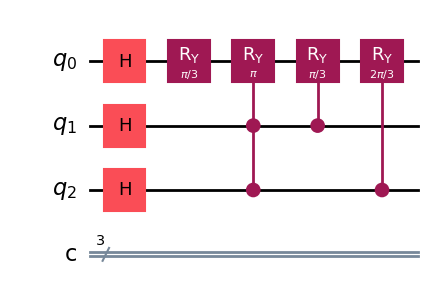

In [14]:
circ=QuantumCircuit(3,3)
ccry=RYGate(math.pi).control(2)
ccry1=RYGate(math.pi/6).control(2)
for qubit in range(3):
    circ.h(qubit)
circ.ry(math.pi/3,0)
circ.append(ccry,[1,2,0])
#circ.append(ccry1,[0,2,1])
circ.cry(math.pi/3,1,0)
circ.cry(2*math.pi/3,2,0)
circ.draw("mpl")

In [15]:
state=Statevector(circ)
display(array_to_latex(state.data, prefix="|\\psi\\rangle = "))
print(state)

<IPython.core.display.Latex object>

Statevector([ 0.12940952+0.j,  0.48296291+0.j, -0.12940952+0.j,
              0.48296291+0.j, -0.35355339+0.j,  0.35355339+0.j,
             -0.12940952+0.j, -0.48296291+0.j],
            dims=(2, 2, 2))


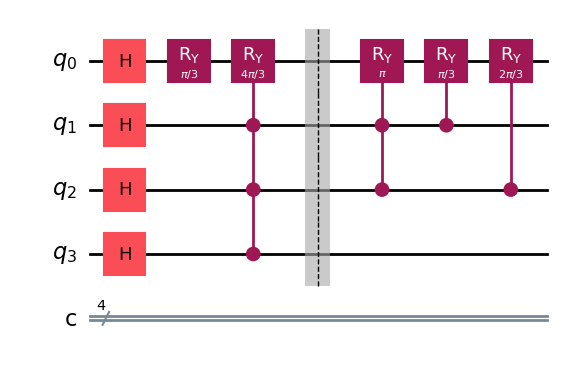

In [16]:
circ=QuantumCircuit(4,4)
ccry=RYGate(math.pi).control(2)
ccry1=RYGate(math.pi/6).control(2)
cccry=RYGate(4*math.pi/3).control(3)
for qubit in range(4):
    circ.h(qubit)
circ.ry(math.pi/3,0)
circ.append(cccry,[1,2,3,0])
circ.barrier(0,1,2,3)
circ.append(ccry,[1,2,0])
#circ.append(ccry1,[0,2,1])
circ.cry(math.pi/3,1,0)
circ.cry(2*math.pi/3,2,0)
circ.draw("mpl")

In [17]:
state=Statevector(circ)
display(array_to_latex(state.data, prefix="|\\psi\\rangle = "))
print(state)

<IPython.core.display.Latex object>

Statevector([ 0.09150635+0.j,  0.34150635+0.j, -0.09150635+0.j,
              0.34150635+0.j, -0.25      +0.j,  0.25      +0.j,
             -0.09150635+0.j, -0.34150635+0.j,  0.09150635+0.j,
              0.34150635+0.j, -0.09150635+0.j,  0.34150635+0.j,
             -0.25      +0.j,  0.25      +0.j,  0.34150635+0.j,
              0.09150635+0.j],
            dims=(2, 2, 2, 2))
